In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [2]:

if __name__ == '__main__':

    path = "../data-resampled/"

    hour_clock = []

    q = 0
    for root, dir, files in os.walk(path):
        
        for file in files:
            hour_real = file[6:8]
            minute_real = file[8:10]
            hour_clock.append(cv.cvtColor(cv.imread(os.path.join(root,file)), cv.COLOR_BGR2GRAY))
            q+=1
            if q == 20:
                break

        break




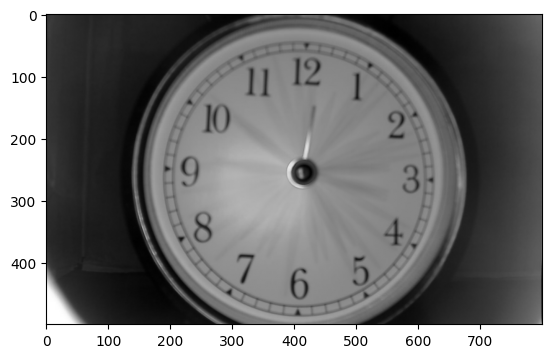

In [3]:

stacked = np.stack(hour_clock, axis=0)

overlay = np.mean(stacked, axis=0)


plt.imshow(overlay, cmap="gray")

Después de haber realizado nuestro template lo que hacemos es comenzar el preprocesamiento de la imagen que vamos a leer.

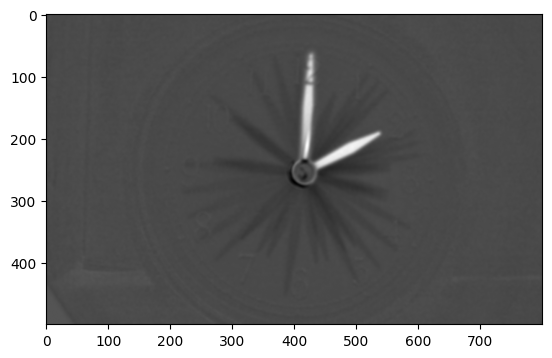

In [4]:
# Para reducir ruido aplicamos blur tanto en el overlay como en la imagen a leer.

im = cv.cvtColor(cv.imread("../data-resampled/clock_0200.png"), cv.COLOR_BGR2GRAY)


kernel_size = (5,5)


im = cv.GaussianBlur(im, kernel_size,2)
overlay = cv.GaussianBlur(overlay, kernel_size, 2)


clock_hands = overlay - im

plt.imshow(clock_hands, cmap="gray")



# Umbralization!


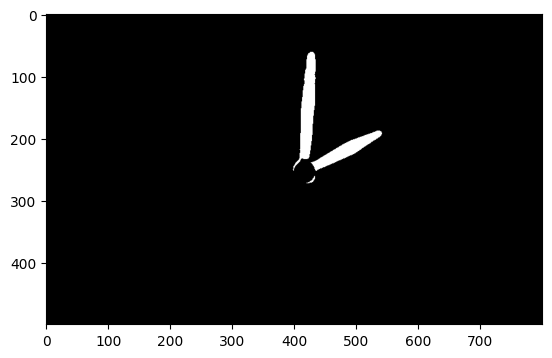

In [5]:
def umbralization(img,t, option1, option2):
    M,N = img.shape

    result = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            result[i,j] = option1 if img[i,j]  <= t  else option2


    return result



umbralized = 255 - umbralization(clock_hands,10, 255, 0) 
plt.imshow(umbralized, cmap="gray")
plt.show()

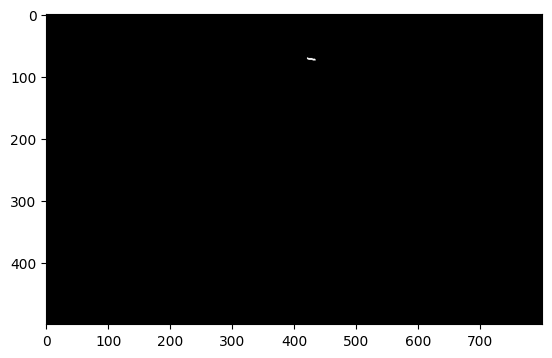

In [6]:
circle_1_minutes = np.zeros((im.shape))
center = (400,250)
cv.circle(circle_1_minutes, center, 180,(255,0,0), 2)
minutes = np.multiply(circle_1_minutes, umbralized)
plt.imshow(minutes, cmap="gray")


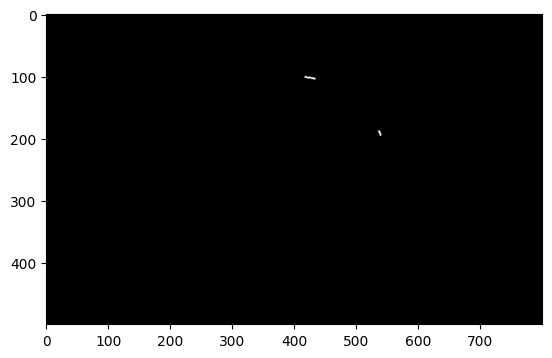

In [7]:
circle_2_hours = np.zeros((im.shape))
cv.circle(circle_2_hours, center, 150,(255,255,255), 2)
hours = circle_2_hours*umbralized
plt.imshow(hours, cmap="gray")



# Hallamos los minutos

In [8]:
x_minutes,y_minutes = np.where(minutes > 0)

x_centro, y_centro = center


distance_minutes = np.sqrt((x_minutes-x_centro)**2 + (y_minutes-y_centro)**2)

manecilla_grande_idx = np.argmax(distance_minutes)
distance_minutes[manecilla_grande_idx]





np.float64(375.59685834681846)

In [9]:
x_punta_g, y_punta_g = x_minutes[manecilla_grande_idx], y_minutes[manecilla_grande_idx]


dy = -(y_punta_g - y_centro)   
dx =  (x_punta_g - x_centro)  


theta = np.arctan2(dy,dx)
theta = np.degrees(np.arctan2(dy, dx))

pi_to_90d = np.degrees(np.pi/2)
pi_to_360d = np.degrees(2*np.pi)

minutes_output = ((((pi_to_90d) - theta) % pi_to_360d)/6)

minutes_output

np.float64(40.14027997286225)

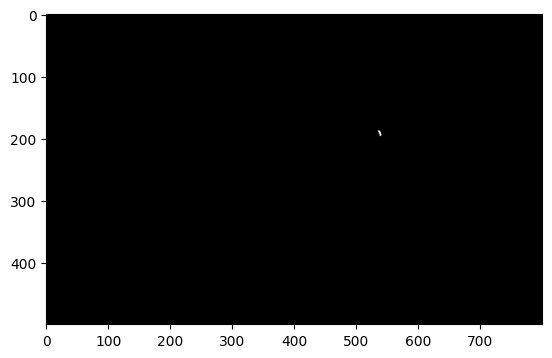

In [10]:
hours = hours.copy()

cv.circle(hours, (int(y_punta_g), int(x_punta_g)), 100,1, -1)
plt.imshow(hours, cmap="gray")

# Hallamos las horas.

In [11]:
x,y = np.where(hours > 0)


distance = np.sqrt((x-x_centro)**2 + (y-y_centro)**2)


manecilla_pequeña_idx = np.argmax(distance)
distance[manecilla_grande_idx]



np.float64(422.8108324061719)

In [12]:

x_punta, y_punta = x[manecilla_pequeña_idx], y[manecilla_pequeña_idx]

dy = -(y_punta - y_centro)   
dx =  (x_punta - x_centro)  
theta_h = np.degrees(np.arctan2(dy, dx))

pi_to_90d = np.degrees(np.pi/2)
pi_to_360d = np.degrees(2*np.pi)

hour = (((((pi_to_90d) - theta_h) % pi_to_360d)/30))

theta_h

np.float64(-147.78907227632624)

In [13]:
x_punta

np.int64(0)

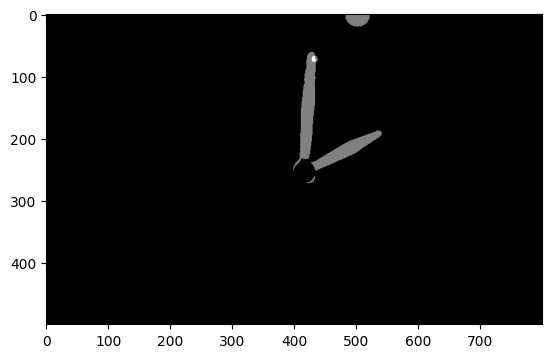

In [14]:
test = np.zeros(im.shape, dtype=np.uint8)
cv.circle(test, (int(y_punta_g), int(x_punta_g)), 5, (255,255,255), -1)
cv.circle(test, (int(y_punta), int(x_punta)), 20, (255,255,255), -1)

plt.imshow(test+umbralized, cmap="gray")